# Train world model

This notebook uses the balanced Dreamer-style recipe:
- KL scale 1.0 with a free-nats floor (so `z` is not pure noise, but also isn't
  forced to match the prior before it has anything useful to encode)
- Aux encoder→pixel recon (keeps perception sharp even if the RSSM lags)
- L1 recon at moderate scale

**Read this before panicking at a gray recon panel:** the decoder is
randomly initialized, so at step 1 its output is near-constant (~gray after
converting back to uint8) no matter how good the recipe is. `image_every`
is synced to `log_every` so the recon grid refreshes every time the loss
curve does — within the first ~50-100 steps you should see real structure
appear. If it's still flat after a few hundred steps, *that's* the signal
something is wrong, not step 1 looking flat.

Watch two recon curves: `recon` (`[h,z]`) and `recon_embed` (encoder). The
embed path should get readable structure first; `[h,z]` follows.

The top-left chart plots each term's **actual contribution to the total
loss** (i.e. already multiplied by its own `*_scale`, matching what
`world_model_loss` sums into `total`). `kl` looks tiny in isolation
(`0.6 = 0.5*kl_dyn + 0.1*kl_rep` at the free-nats floor) purely because
`dyn_scale`/`rep_scale` are small -- once `recon_scale=5.0` is applied to the
raw ~0.1-0.2 pixel loss, recon and kl end up roughly the same size. If you
ever want the raw, un-scaled per-term values instead, they're still in
`history` (e.g. `history[-1]["recon"]`).

The `kl_dyn_raw` / `kl_rep_raw` panel shows the *total* KL of the latent
(summed across all `stoch` categorical variables — they're independent, so
joint KL is a sum, not an average). It's completely normal for this to sit
at or below the `free_nats` line for the entire run — the free-nats floor
exists exactly so the model pays no extra penalty for living at that budget.
**It does not need to cross the line, ever.** What actually matters:
it shouldn't collapse toward 0 (dead latent, posterior == prior) and
shouldn't blow up to huge values (posterior ignoring the prior completely,
bad for imagination). A curve that dips, then plateaus somewhere in the
0.3-1.5 nat range, is healthy.

A full 12000-step run is ~90-100 minutes on Apple Silicon MPS. Set
`STEPS_OVERRIDE = 500` for a quick smoke test before committing to a full run.

**Latent capacity bumped 16x16 -> 32x32** (DreamerV3's standard size,
arXiv:2301.04104) after a prior run's `recon` genuinely plateaued around step
8-9k (confirmed via the trend readout, not just noise) with visibly blurry
`[h,z]` reconstructions. This is a real architecture/checkpoint shape change
-- old checkpoints under `checkpoints/m3_world_model/` won't load; start
fresh with `RESUME = None`.

**Set expectations correctly:** the `[h,z]` panel will likely never look as
sharp as M1's `recon_final.png`. M1's autoencoder uses U-Net skip connections
straight from the raw input plus a near-copy residual head -- a legitimate
trick for a pure image-in/image-out task, but structurally impossible for the
`[h,z]` decoder, which must reconstruct purely from imagined state with zero
access to real pixels during rollouts (that's the whole point of a world
model). The only honest lever for its sharpness is real latent/model
capacity, which is what this change increases. `embed` (bypassing the RSSM
entirely) can look sharper than `[h,z]` -- that gap is expected, not a bug.

Kernel → Restart → run all. `RESUME = None`.


In [1]:
from __future__ import annotations

import importlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from IPython.display import clear_output, display
from torch.utils.tensorboard import SummaryWriter

import models.decoder as decoder_mod
import models.world_model as wm_mod
import training.losses as losses_mod
from models.preprocess import nchw_float_to_nhwc_uint8, nhwc_uint8_to_nchw_float
from training.device import get_device
from training.replay_buffer import ReplayBuffer, collect_random_episodes

importlib.reload(losses_mod)
importlib.reload(decoder_mod)
importlib.reload(wm_mod)
world_model_loss = losses_mod.world_model_loss
WorldModel = wm_mod.WorldModel

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

%matplotlib inline

CONFIG = Path("configs/m3_world_model.yaml")
RESUME = None
STEPS_OVERRIDE: int | None = None
RECOLLECT = False  # True only if you still need the 80-episode dump

with CONFIG.open() as f:
    cfg = yaml.safe_load(f)

seed = int(cfg["seed"])
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = get_device()
print(f"device: {device}")
if device.type != "mps":
    print(
        "WARNING: not running on MPS -- training will be ~10-20x slower on CPU. "
        "Check torch.backends.mps.is_available() and that this isn't running "
        "inside a sandboxed shell/container without GPU access."
    )
print(
    f"recon_scale={cfg['train']['recon_scale']} "
    f"recon_embed_scale={cfg['train'].get('recon_embed_scale')} "
    f"kl_scale={cfg['train']['kl_scale']} free_nats={cfg['train']['free_nats']}"
)


device: mps
recon_scale=5.0 recon_embed_scale=5.0 kl_scale=1.0 free_nats=1.0


In [2]:
replay_path = Path(cfg["collect"]["out_path"])
if RECOLLECT or not replay_path.exists():
    print(f"collecting {cfg['collect']['num_episodes']} episodes…")
    buf = collect_random_episodes(
        env_id=str(cfg["env"]["id"]),
        num_episodes=int(cfg["collect"]["num_episodes"]),
        max_episode_steps=int(cfg["collect"]["max_episode_steps"]),
        action_dim=int(cfg["env"]["action_dim"]),
        seed=seed,
    )
    replay_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(buf.state_dict(), replay_path)
    print(f"wrote {replay_path}: episodes={len(buf)} steps={buf.num_steps}")
else:
    print(f"using existing {replay_path}")

buffer = ReplayBuffer(seed=seed)
buffer.load_state_dict(torch.load(replay_path, weights_only=False))
print(f"replay: episodes={len(buffer)} steps={buffer.num_steps}")


using existing data/m3_replay.pt
replay: episodes=80 steps=13669


In [3]:
enc, rssm, dec, heads, train_cfg = (
    cfg["encoder"],
    cfg["rssm"],
    cfg.get("decoder", {}),
    cfg.get("heads", {}),
    cfg["train"],
)
model = WorldModel.from_config_dims(
    embed_dim=int(enc["embed_dim"]),
    encoder_channels=tuple(int(c) for c in enc["channels"]),
    action_dim=int(cfg["env"]["action_dim"]),
    deter_dim=int(rssm["deter_dim"]),
    stoch=int(rssm["stoch"]),
    classes=int(rssm["classes"]),
    hidden=int(rssm["hidden"]),
    unimix=float(rssm.get("unimix", 0.01)),
    act=str(rssm.get("act", "silu")),
    initial=str(rssm.get("initial", "learned")),
    rec_depth=int(rssm.get("rec_depth", 1)),
    decoder_channels=tuple(int(c) for c in dec.get("channels", [512, 256, 128, 64])),
    head_hidden=int(heads.get("hidden", 512)),
    head_layers=int(heads.get("layers", 2)),
).to(device)
optim = torch.optim.Adam(model.parameters(), lr=float(train_cfg["lr"]))
start_step = 0
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")


params: 52.15M


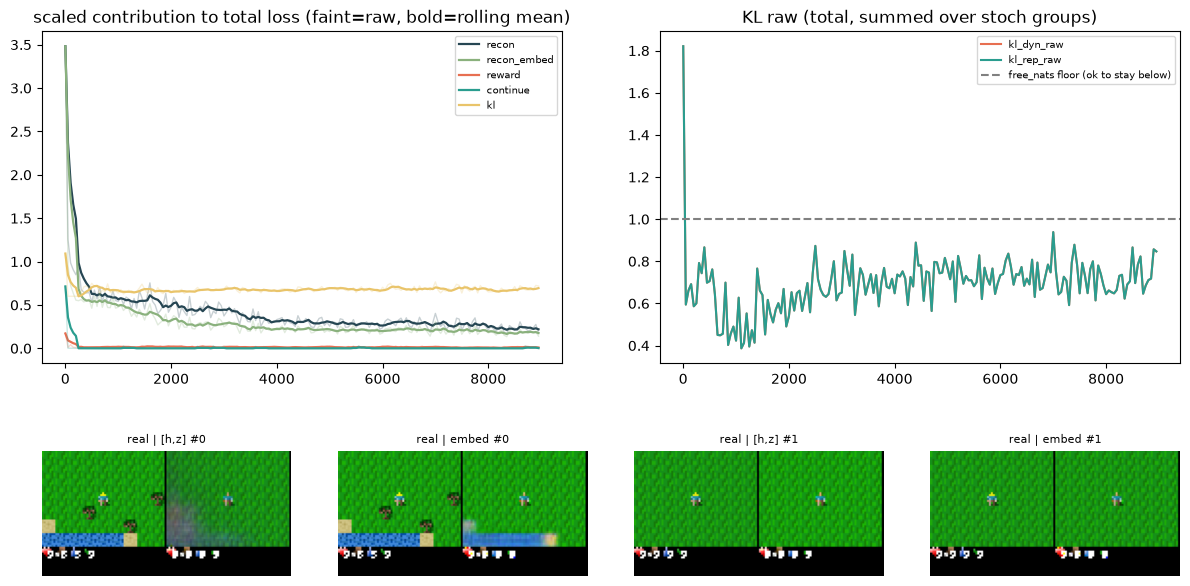

step  8950/12000  recon=0.0345 emb=0.0282  kl_raw=0.847/0.847
  scaled contributions to total: recon=0.173 recon_embed=0.141 reward=0.007 continue=0.000 kl=0.718
  recon trend: last 500 steps avg=0.0462 vs prior 500 steps avg=0.0454 (-1.9%)


KeyboardInterrupt: 

In [4]:
log_dir = Path(train_cfg["log_dir"])
ckpt_dir = Path(train_cfg["checkpoint_dir"])
results_dir = Path(train_cfg["results_dir"])
for p in (log_dir, ckpt_dir, results_dir):
    p.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(log_dir))

steps = int(STEPS_OVERRIDE) if STEPS_OVERRIDE is not None else int(train_cfg["steps"])
batch_size = int(train_cfg["batch_size"])
seq_len = int(train_cfg["seq_len"])
log_every = int(train_cfg["log_every"])
image_every = int(train_cfg["image_every"])
ckpt_every = int(train_cfg["checkpoint_every"])

import time

history: list[dict] = []
last_recon_vis = None
last_log_time = time.time()
last_log_step = start_step


def show_progress(history, recon_vis, steps_per_sec=None):
    clear_output(wait=True)
    xs = [h["step"] for h in history]
    fig = plt.figure(figsize=(12, 7))
    ax0 = fig.add_subplot(2, 2, 1)
    # Plot each term's ACTUAL contribution to `total` (i.e. multiplied by its
    # own *_scale). `kl` already bakes in dyn_scale/rep_scale internally, so
    # comparing it directly against unscaled recon/recon_embed made recon look
    # negligible even when it was contributing just as much to the real total.
    scales = {
        "recon": float(train_cfg["recon_scale"]),
        "recon_embed": float(train_cfg.get("recon_embed_scale", 1.0)),
        "reward": float(train_cfg["reward_scale"]),
        "continue": float(train_cfg["continue_scale"]),
        "kl": float(train_cfg["kl_scale"]),
    }
    def rolling_mean(values: list[float], window: int = 5) -> list[float]:
        out = []
        for i in range(len(values)):
            lo = max(0, i - window + 1)
            out.append(sum(values[lo : i + 1]) / (i - lo + 1))
        return out

    for key, color in [
        ("recon", "#264653"),
        ("recon_embed", "#8ab17d"),
        ("reward", "#e76f51"),
        ("continue", "#2a9d8f"),
        ("kl", "#e9c46a"),
    ]:
        raw = [h[key] * scales[key] for h in history]
        # Each point is a single small (batch_size=4) minibatch's loss, so the
        # raw curve is noisy even while the underlying trend is improving. Plot
        # the noisy trace faint + a rolling mean on top so the trend is legible.
        ax0.plot(xs, raw, color=color, alpha=0.25, linewidth=1)
        ax0.plot(xs, rolling_mean(raw), label=key, color=color, linewidth=1.6)
    ax0.set_title("scaled contribution to total loss (faint=raw, bold=rolling mean)")
    ax0.legend(fontsize=7)

    ax1 = fig.add_subplot(2, 2, 2)
    ax1.plot(xs, [h["kl_dyn_raw"] for h in history], label="kl_dyn_raw", color="#e76f51")
    ax1.plot(xs, [h["kl_rep_raw"] for h in history], label="kl_rep_raw", color="#2a9d8f")
    # This is a MINIMUM the KL gets no penalty for staying at/below, not a target
    # it needs to cross -- see DreamerV3 paper eq. 5: max(1, KL) exists precisely
    # to switch the KL loss off once already small, not to pull it upward.
    ax1.axhline(
        float(train_cfg["free_nats"]), color="gray", ls="--", label="free_nats floor (ok to stay below)"
    )
    ax1.set_title("KL raw (total, summed over stoch groups)")
    ax1.legend(fontsize=7)

    if recon_vis is not None:
        real, pred_hz, pred_emb = recon_vis
        for i in range(min(2, real.shape[0])):
            ax = fig.add_subplot(2, 4, 5 + i * 2)
            ax.imshow(np.concatenate([real[i].numpy(), pred_hz[i].numpy()], axis=1))
            ax.set_title(f"real | [h,z] #{i}", fontsize=8)
            ax.axis("off")
            ax = fig.add_subplot(2, 4, 6 + i * 2)
            ax.imshow(np.concatenate([real[i].numpy(), pred_emb[i].numpy()], axis=1))
            ax.set_title(f"real | embed #{i}", fontsize=8)
            ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    h = history[-1]
    sps = f" ({steps_per_sec:.2f} steps/s)" if steps_per_sec else ""
    contrib_str = " ".join(f"{k}={h[k] * scales[k]:.3f}" for k in scales)
    print(
        f"step {h['step']:5d}/{start_step + steps}  "
        f"recon={h['recon']:.4f} emb={h['recon_embed']:.4f}  "
        f"kl_raw={h['kl_dyn_raw']:.3f}/{h['kl_rep_raw']:.3f}{sps}\n"
        f"  scaled contributions to total: {contrib_str}"
    )
    # De-noise the "is it actually improving?" question: compare the mean of
    # the last chunk of logged points against the chunk before it, instead of
    # reading two single noisy points off the chart.
    n = len(history)
    chunk = max(1, min(10, n // 2))
    if n >= 2 * chunk:
        recent = sum(x["recon"] for x in history[-chunk:]) / chunk
        prior = sum(x["recon"] for x in history[-2 * chunk : -chunk]) / chunk
        pct = 100.0 * (1.0 - recent / max(prior, 1e-8))
        window_steps = chunk * log_every
        print(
            f"  recon trend: last {window_steps} steps avg={recent:.4f} vs "
            f"prior {window_steps} steps avg={prior:.4f} ({pct:+.1f}%)"
        )


model.train()
print(f"training {steps} steps on {device}…")
for step in range(start_step + 1, start_step + steps + 1):
    batch = buffer.sample(batch_size, seq_len)
    obs = batch["obs"].to(device)
    out = model(obs, batch["actions"].to(device))
    b, t = obs.shape[:2]
    obs_f = nhwc_uint8_to_nchw_float(obs.reshape(b * t, *obs.shape[2:])).view(b, t, 3, 64, 64)
    loss = world_model_loss(
        obs=obs_f,
        recon=out.recon,
        recon_embed=out.recon_embed,
        reward=batch["rewards"].to(device),
        reward_pred=out.reward_pred,
        cont=batch["cont"].to(device),
        cont_logit=out.cont_logit,
        post_logits=out.rssm.posterior_logits,
        prior_logits=out.rssm.prior_logits,
        unimix=model.rssm.unimix,
        dyn_scale=float(train_cfg["dyn_scale"]),
        rep_scale=float(train_cfg["rep_scale"]),
        free_nats=float(train_cfg["free_nats"]),
        recon_scale=float(train_cfg["recon_scale"]),
        recon_embed_scale=float(train_cfg.get("recon_embed_scale", 1.0)),
        reward_scale=float(train_cfg["reward_scale"]),
        continue_scale=float(train_cfg["continue_scale"]),
        kl_scale=float(train_cfg["kl_scale"]),
        recon_loss_type=str(train_cfg.get("recon_loss", "l1")),
    )
    optim.zero_grad(set_to_none=True)
    loss.total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 100.0)
    optim.step()

    metrics = {
        "step": step,
        "total": float(loss.total.detach()),
        "recon": float(loss.recon.detach()),
        "recon_embed": float(loss.recon_embed.detach()),
        "reward": float(loss.reward.detach()),
        "continue": float(loss.continue_loss.detach()),
        "kl": float(loss.kl.detach()),
        "kl_dyn": float(loss.kl_dyn.detach()),
        "kl_rep": float(loss.kl_rep.detach()),
        "kl_dyn_raw": float(loss.kl_dyn_raw.detach()),
        "kl_rep_raw": float(loss.kl_rep_raw.detach()),
    }

    if step % log_every == 0 or step == start_step + 1:
        for k, v in metrics.items():
            if k != "step":
                writer.add_scalar(f"m3/{k}", v, step)
        history.append(metrics)
        now = time.time()
        steps_per_sec = (step - last_log_step) / max(now - last_log_time, 1e-6)
        last_log_time, last_log_step = now, step
        show_progress(history, last_recon_vis, steps_per_sec)

    if step % image_every == 0 or step == start_step + 1:
        model.eval()
        with torch.no_grad():
            vis = buffer.sample(min(4, batch_size), seq_len)
            v_out = model(vis["obs"].to(device), vis["actions"].to(device))
            real = vis["obs"][:, 0].cpu()
            pred_hz = nchw_float_to_nhwc_uint8(v_out.recon[:, 0].detach().cpu())
            pred_emb = nchw_float_to_nhwc_uint8(v_out.recon_embed[:, 0].detach().cpu())
            last_recon_vis = (real, pred_hz, pred_emb)
            from PIL import Image

            strips = [
                np.concatenate([real[i].numpy(), pred_hz[i].numpy(), pred_emb[i].numpy()], axis=1)
                for i in range(real.shape[0])
            ]
            Image.fromarray(np.concatenate(strips, axis=0), mode="RGB").save(
                results_dir / f"recon_step_{step:05d}.png"
            )
        model.train()
        if history:
            show_progress(history, last_recon_vis)

    if step % ckpt_every == 0:
        path = ckpt_dir / f"ckpt_step_{step:05d}.pt"
        torch.save({"step": step, "model": model.state_dict(), "optim": optim.state_dict()}, path)
        print(f"wrote {path}")

final = ckpt_dir / "ckpt_final.pt"
torch.save({"step": start_step + steps, "model": model.state_dict(), "optim": optim.state_dict()}, final)
(results_dir / "train_metrics.json").write_text(json.dumps(history, indent=2))
writer.flush(); writer.close()
show_progress(history, last_recon_vis)

# Definitive end-of-run grid (larger batch, holdout-ish sample) for the README-style
# before/after comparison, independent of whatever image_every last landed on.
model.eval()
with torch.no_grad():
    vis = buffer.sample(8, seq_len)
    v_out = model(vis["obs"].to(device), vis["actions"].to(device))
    real = vis["obs"][:, -1].cpu()
    pred_hz = nchw_float_to_nhwc_uint8(v_out.recon[:, -1].detach().cpu())
    pred_emb = nchw_float_to_nhwc_uint8(v_out.recon_embed[:, -1].detach().cpu())
    from PIL import Image

    strips = [
        np.concatenate([real[i].numpy(), pred_hz[i].numpy(), pred_emb[i].numpy()], axis=1)
        for i in range(real.shape[0])
    ]
    Image.fromarray(np.concatenate(strips, axis=0), mode="RGB").save(results_dir / "recon_final.png")
model.train()
print("done", final)


## Exit criteria — did this run actually work?

A healthy M3 run should show all of the following. This cell checks them
automatically instead of relying on eyeballing the curves.

In [ ]:
assert len(history) >= 2, "need at least two logged points to judge a trend"

first, last = history[0], history[-1]
checks: list[tuple[str, bool, str]] = []


def pct_drop(key: str) -> float:
    return 1.0 - (last[key] / max(first[key], 1e-8))


for key, min_drop in [("recon", 0.5), ("recon_embed", 0.5)]:
    drop = pct_drop(key)
    checks.append(
        (
            f"{key} loss dropped >= {min_drop:.0%} (first={first[key]:.4f} -> last={last[key]:.4f}, "
            f"actual={drop:.0%})",
            drop >= min_drop,
            "recon isn't improving — check lr, recon_scale, or a decoder/data bug",
        )
    )

# kl_dyn_raw is the TOTAL KL of the latent (summed over stoch groups). It is
# expected to sit at/below free_nats for most (or all) of training -- that's
# what the free-nats floor is for, not a target to exceed. The actual failure
# modes are collapse toward ~0 (dead latent) or blowing up to many nats
# (posterior ignoring the prior, bad for imagination rollouts).
kl_dyn_last = last["kl_dyn_raw"]
checks.append(
    (
        f"kl_dyn_raw isn't dead (last={kl_dyn_last:.3f} > 0.02)",
        kl_dyn_last > 0.02,
        "posterior has collapsed onto the prior -- latent carries ~no information",
    )
)
checks.append(
    (
        f"kl_dyn_raw hasn't exploded (last={kl_dyn_last:.3f} < 30.0)",
        kl_dyn_last < 30.0,
        "posterior is ignoring the prior entirely -- imagination rollouts will drift badly",
    )
)

# Pixel-collapse check: decoder output std should be in the same ballpark as
# real-image std, not near zero (solid color).
model.eval()
with torch.no_grad():
    vis = buffer.sample(8, seq_len)
    v_out = model(vis["obs"].to(device), vis["actions"].to(device))
    obs_f = nhwc_uint8_to_nchw_float(vis["obs"].to(device))
    obs_std = float(obs_f.std())
    recon_std = float(v_out.recon.std())
    embed_std = float(v_out.recon_embed.std())
model.train()

for name, std in [("recon", recon_std), ("recon_embed", embed_std)]:
    ratio = std / max(obs_std, 1e-8)
    checks.append(
        (
            f"{name} pixel std is close to real ({name}_std={std:.4f} vs obs_std={obs_std:.4f}, "
            f"ratio={ratio:.2f})",
            ratio > 0.4,
            f"{name} has collapsed toward a constant (solid-color) output",
        )
    )

print(f"steps trained: {last['step']}\n")
all_pass = True
for description, ok, hint in checks:
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {description}")
    if not ok:
        print(f"       -> {hint}")
        all_pass = False

print()
print("RESULT:", "PASS — M3 world model looks healthy" if all_pass else "FAIL — see hints above")